In [5]:
# 0) Imports et chargement
import os
import pandas as pd
import matplotlib.pyplot as plt

# (Optionnel) statsmodels pour la décomposition
# !pip install statsmodels  # décommentez si nécessaire
from statsmodels.tsa.seasonal import seasonal_decompose

import kagglehub

# Téléchargement
path = kagglehub.dataset_download("erogluegemen/airline-passengers")
print("Dossier Kaggle :", path)

# Fichier CSV (nom le plus courant pour ce dataset)
csv_path = os.path.join(path, "airline-passengers.csv")

# Lecture du CSV
df_raw = pd.read_csv(csv_path)
print(df_raw.head())


Using Colab cache for faster access to the 'airline-passengers' dataset.
Dossier Kaggle : /kaggle/input/airline-passengers
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [6]:
# 2) Aperçu des 5 premières lignes
df_raw.head()


,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [9]:
# 3) Mise en forme temporelle (détection souple des colonnes)
df = df_raw.copy()

date_col = "Month" if "Month" in df.columns else ("month" if "month" in df.columns else df.columns[0])
value_col = "Passengers" if "Passengers" in df.columns else ("passengers" if "passengers" in df.columns else df.columns[1])

df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col).sort_index()

# Assure une fréquence mensuelle (début de mois)
df = df.asfreq("MS")

print("Colonne date  :", date_col)
print("Colonne valeur:", value_col)
df.head()


Colonne date  : month
Colonne valeur: total_passengers


,total_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


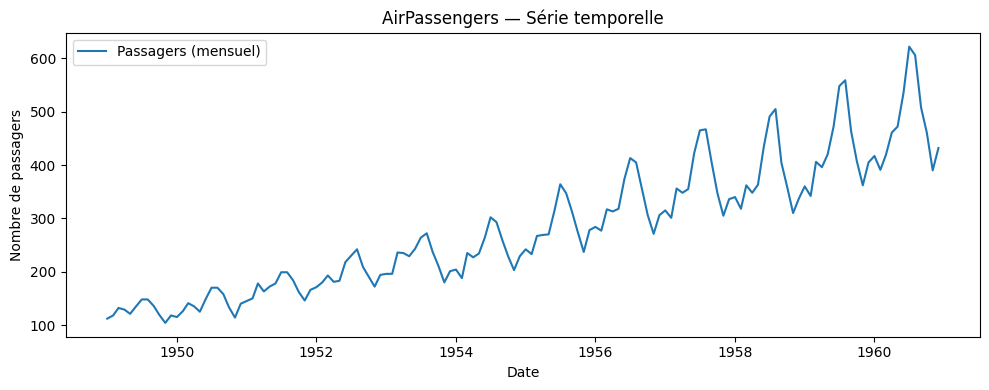

In [10]:
# 4) Visualisation de la série
plt.figure(figsize=(10, 4))
plt.plot(df.index, df[value_col], label="Passagers (mensuel)")
plt.title("AirPassengers — Série temporelle")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.tight_layout()
plt.show()


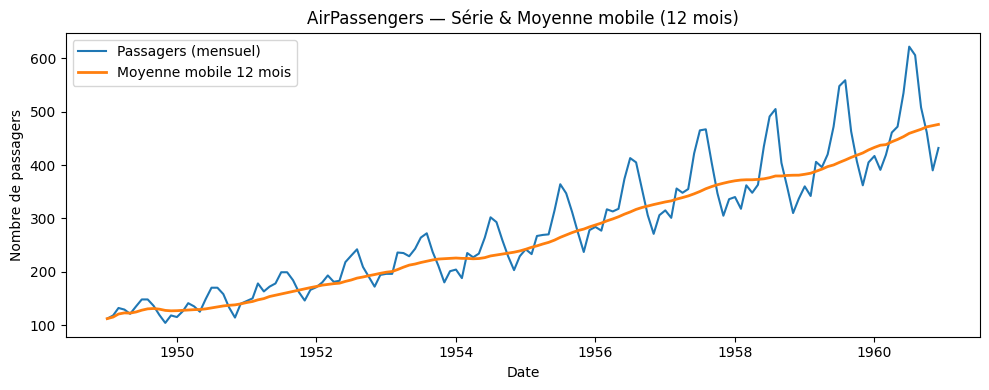

,MA_12
month,
1949-01-01,112.000000
1949-02-01,115.000000
1949-03-01,120.666667
1949-04-01,122.750000
1949-05-01,122.400000
1949-06-01,124.500000
1949-07-01,127.857143
1949-08-01,130.375000
1949-09-01,131.000000


In [11]:
# 5) Moyenne mobile 12 mois
df["MA_12"] = df[value_col].rolling(window=12, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(df.index, df[value_col], label="Passagers (mensuel)")
plt.plot(df.index, df["MA_12"], label="Moyenne mobile 12 mois", linewidth=2)
plt.title("AirPassengers — Série & Moyenne mobile (12 mois)")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.tight_layout()
plt.show()

# (optionnel) aperçu des premières valeurs de la moyenne mobile
df[["MA_12"]].head(15)


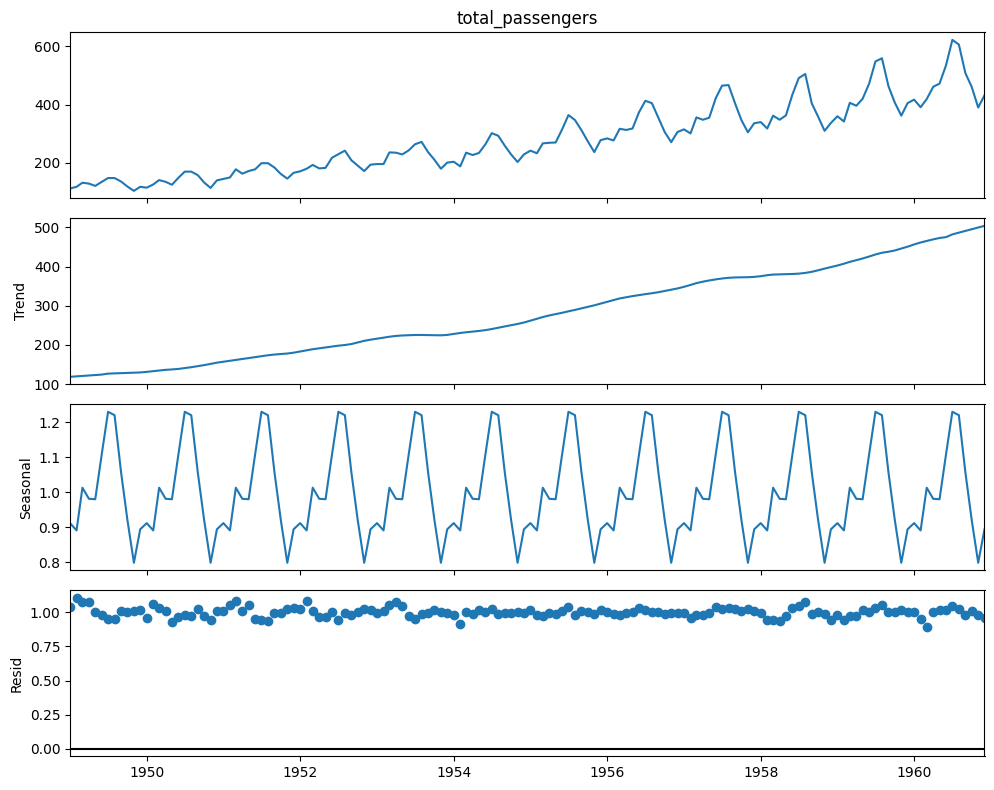

,observed,trend,seasonal,resid
month,,,,
1949-01-01,112.0,118.588481,0.911256,1.036418
1949-02-01,118.0,119.734169,0.890342,1.106896
1949-03-01,132.0,120.879856,1.012397,1.078621
1949-04-01,129.0,122.025544,0.980719,1.077940
1949-05-01,121.0,123.171232,0.979495,1.002938
1949-06-01,135.0,124.316919,1.108310,0.979811
1949-07-01,148.0,126.791667,1.229422,0.949445
1949-08-01,148.0,127.250000,1.219640,0.953613
1949-09-01,136.0,127.958333,1.056262,1.006233


In [12]:
# 6) Décomposition saisonnière
# Pour AirPassengers, la décomposition multiplicative est souvent plus adaptée (variance croissante)
result = seasonal_decompose(
    df[value_col],
    model="multiplicative",
    period=12,
    extrapolate_trend="freq"
)

fig = result.plot()
fig.set_size_inches(10, 8)
fig.tight_layout()
plt.show()

# (optionnel) construire un DataFrame avec les composantes
decomp_df = pd.DataFrame({
    "observed": result.observed,
    "trend": result.trend,
    "seasonal": result.seasonal,
    "resid": result.resid
})
decomp_df.head(12)
